# Market Regime Dynamics

## Objective

The objective of this notebook is to analyze the temporal behavior of the market regimes identified in the previous stage of the project. Rather than focusing on discovering new regimes, this notebook examines how the identified market states evolve over time, how frequently transitions occur between them, and how persistent each regime is throughout the historical period.

By studying the dynamics of market regimes, this analysis moves beyond static cluster interpretation to provide a deeper understanding of market behavior. The insights obtained in this notebook establish the foundation for future predictive models and decision-making frameworks that incorporate changes in market conditions.

## Notebook Roadmap

This notebook is organized into the following stages:

1. Prepare the market regime dataset.
2. Explore the historical evolution of market regimes.
3. Analyze regime transitions.
4. Measure regime persistence.
5. Summarize the dynamic behavior of the identified market regimes.

-----

## Environment Setup

Before beginning the market regime dynamics analysis, the required libraries, project configuration, and datasets are loaded. This initialization step ensures that all subsequent analyses are performed using a consistent and reproducible environment.

In [1]:
# ==========================================
# Import Libraries and Load Configuration
# ==========================================
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap
import numpy as np
import seaborn as sns
import os 
import sys

# Absoulte Path To The Project Route
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

from config import *

In [2]:
# ==========================================
# Asset Names
# ==========================================
if len(ASSETS) != 1:
    raise ValueError(
        "This notebook is designed for single-asset analysis."
    )

asset_name = (
    ASSETS[0]
    .lower()
    .replace("-", "_")
)

In [3]:
# ==========================================
# Load Dataset
# ==========================================

market_regime_path = os.path.join(
    PROCESSED_DATA_PATH,
    f"{asset_name}_market_regime.csv"
)

market_regime_df = pd.read_csv(
    market_regime_path,
    parse_dates=["Date"],
    index_col = "Date"
)

In [4]:
# ==========================================
# Verify Dataset
# ==========================================
print("Dataset shape:", market_regime_df.shape)

market_regime_df.head()
market_regime_df.info()

Dataset shape: (3065, 5)
<class 'pandas.DataFrame'>
DatetimeIndex: 3065 entries, 2018-01-31 to 2026-06-22
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Returns        3065 non-null   float64
 1   Volatility     3065 non-null   float64
 2   Momentum       3065 non-null   float64
 3   Cluster_Id     3065 non-null   int64  
 4   Market_Regime  3065 non-null   str    
dtypes: float64(3), int64(1), str(1)
memory usage: 143.7 KB


-----

## Preparing the Market Regime Dataset

The market regime dataset exported in the previous notebook contains the complete output of the market regime detection stage. Before analyzing how market conditions evolve over time, it is important to verify that the dataset includes all the information required for the subsequent analyses.

This preparation step validates the structure of the dataset, confirms the presence of the financial features and market regime labels, and ensures that the observations are organized chronologically. Once these checks are completed, the dataset is ready to support the study of historical regime evolution, transition behavior, and regime persistence.

In [5]:
# ==========================================
# Verify Dataset Structure
# ==========================================
print("Date Range:")
print(f"Start:{market_regime_df.index.min()} ")
print(f"End: {market_regime_df.index.max()}")

print("\nNumber of Observations:")
print(len(market_regime_df))

print("\nMissing Values:")
print(market_regime_df.isnull().sum())

print("\nAvailable Columns:")
print(list(market_regime_df.columns))

print("\nMarket Regimes")
print(market_regime_df["Market_Regime"].value_counts().sort_index())

Date Range:
Start:2018-01-31 00:00:00 
End: 2026-06-22 00:00:00

Number of Observations:
3065

Missing Values:
Returns          0
Volatility       0
Momentum         0
Cluster_Id       0
Market_Regime    0
dtype: int64

Available Columns:
['Returns', 'Volatility', 'Momentum', 'Cluster_Id', 'Market_Regime']

Market Regimes
Market_Regime
High-Volatility Bearish         410
High-Volatility Transition      414
Low-Volatility Neutral         1683
Moderate-Volatility Bullish     558
Name: count, dtype: int64


-----

## Color Palette
Before going further let's stablish a color palette for future charts.

In [6]:
# ==========================================
# Market Regime Color Palette
# ==========================================

REGIME_COLORS = {
    "Moderate-Volatility Bullish": "#2ca02c",   # Green
    "Low-Volatility Neutral": "#1f77b4",        # Blue
    "High-Volatility Transition": "#ff7f0e",    # Orange
    "High-Volatility Bearish": "#d62728"        # Red
}

----

## Historical Evolution of Market Regimes

After identifying and characterizing the different market regimes, the next step is to examine how these regimes evolved throughout the historical period. Rather than analyzing each regime individually, this section focuses on their temporal distribution to understand when different market conditions occurred and how they changed over time.

Visualizing the sequence of market regimes provides valuable context for identifying prolonged periods of stability, bullish trends, bearish phases, and high-volatility transitions. This temporal perspective establishes the foundation for the transition and persistence analyses presented in the following sections.

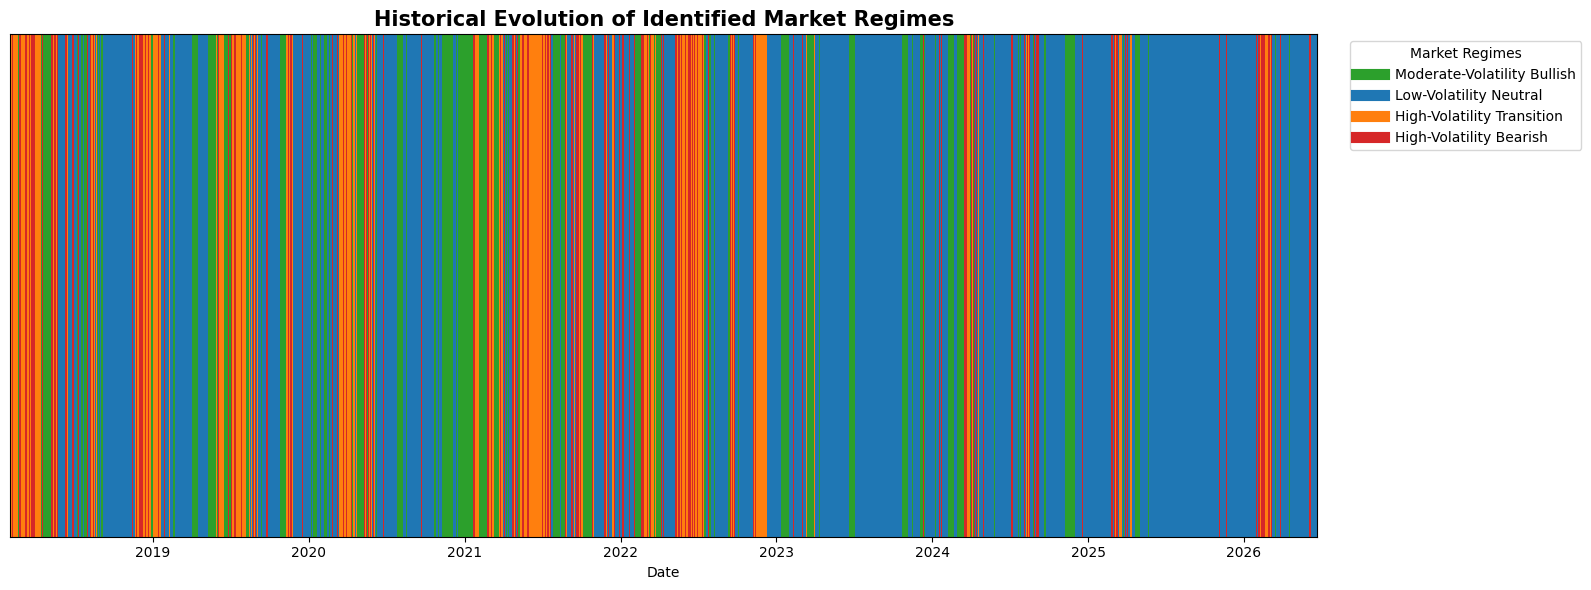

In [7]:
# ==========================================
# Historical Evolution of Market Regimes
# ==========================================

# Financial ordering
regime_order = [
    "Moderate-Volatility Bullish",
    "Low-Volatility Neutral",
    "High-Volatility Transition",
    "High-Volatility Bearish"
]

# Convert regimes into numeric values
regime_to_number = {
    regime: i
    for i, regime in enumerate(regime_order)
}

timeline = (
    market_regime_df["Market_Regime"]
    .map(regime_to_number)
    .values
    .reshape(1, -1)
)

# Consistent colors
cmap = ListedColormap([
    REGIME_COLORS["Moderate-Volatility Bullish"],
    REGIME_COLORS["Low-Volatility Neutral"],
    REGIME_COLORS["High-Volatility Transition"],
    REGIME_COLORS["High-Volatility Bearish"]
])

fig, ax = plt.subplots(figsize=(16, 6))

ax.imshow(
    timeline,
    aspect="auto",
    cmap=cmap,
    interpolation="nearest",
    extent=[
        mdates.date2num(market_regime_df.index.min()),
        mdates.date2num(market_regime_df.index.max()),
        0,
        1
    ]
)

# Formatting
ax.set_yticks([])
ax.set_xlabel("Date")

ax.set_title(
    "Historical Evolution of Identified Market Regimes",
    fontsize=15,
    fontweight="bold"
)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Legend
handles = [
    plt.Line2D(
        [0],
        [0],
        color=REGIME_COLORS[r],
        lw=8,
        label=r
    )
    for r in regime_order
]

ax.legend(
    handles=handles, 
    title="Market Regimes",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Interpretation 
The historical evolution of the identified market regimes reveals that market conditions were not randomly distributed throughout the analyzed period. Instead, the timeline exhibits clear temporal clustering, with extended intervals dominated by specific market regimes.

The Low-Volatility Neutral regime occupies the largest portion of the timeline and becomes particularly dominant after 2023, where long uninterrupted blue segments indicate sustained periods of relatively stable market behavior. This observation is consistent with the frequency analysis presented in the previous notebook.

In contrast, the High-Volatility Transition and High-Volatility Bearish regimes appear more frequently between 2018 and 2022, suggesting that the earlier years of the sample were characterized by repeated episodes of elevated volatility and market stress. These regimes tend to occur in concentrated intervals rather than being evenly distributed over time.

The Moderate-Volatility Bullish regime also appears in distinct clusters, indicating that positive market conditions often persist for multiple consecutive observations before transitioning into another regime.

Overall, the timeline demonstrates that market regimes exhibit meaningful temporal structure, with periods of stability, bullish activity, and high-volatility conditions occurring in identifiable phases. This evidence motivates the next stage of the analysis, which examines how frequently transitions occur between regimes and how persistent each market state tends to be once established.

----

## Regime Transition Analysis
While the previous section examined how market regimes evolved throughout the analyzed period, it did not explicitly describe how the market moved from one regime to another. Understanding these transitions is essential because financial markets are dynamic systems in which conditions continuously evolve rather than remaining permanently in a single state.

A regime transition occurs whenever the market changes from one identified state to another between consecutive observations. By analyzing these transitions, we can determine whether certain market regimes are highly persistent, whether some transitions occur more frequently than others, and whether the market tends to follow recognizable pathways as conditions change.

The objective of this section is to quantify the transitions between market regimes and identify the most common movement patterns observed throughout the historical period. These findings provide a deeper understanding of market dynamics and establish the foundation for the persistence analysis presented in the following section.

In [8]:
# ==========================================
# Build Regime Transition Matrix
# ==========================================

# Create a DataFrame with the current and next market regime
transition_df = pd.DataFrame({
    "Current_Regime": market_regime_df["Market_Regime"],
    "Next_Regime": market_regime_df["Market_Regime"].shift(-1)
})

# Remove the last observation since it has no following regime
transition_df = transition_df.dropna()

# Count transitions bewtween regimes 
transition_matrix = pd.crosstab(
    transition_df["Current_Regime"],
    transition_df["Next_Regime"]
)

# Display transition counts
transition_matrix

Next_Regime,High-Volatility Bearish,High-Volatility Transition,Low-Volatility Neutral,Moderate-Volatility Bullish
Current_Regime,,,,
High-Volatility Bearish,99,168,123,20
High-Volatility Transition,139,205,45,25
Low-Volatility Neutral,133,27,1430,92
Moderate-Volatility Bullish,39,13,85,421


In [9]:
# ==========================================
# Reorder Transition Matrix
# ==========================================

regime_order = [
    "Moderate-Volatility Bullish",
    "Low-Volatility Neutral",
    "High-Volatility Transition",
    "High-Volatility Bearish"
]

transition_matrix = transition_matrix.reindex(
    index=regime_order,
    columns=regime_order
)

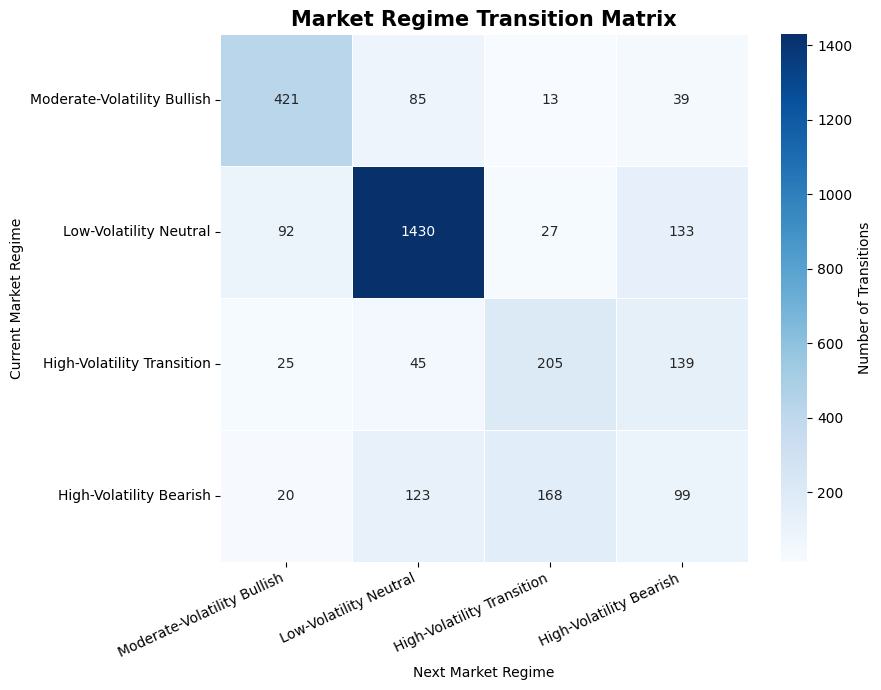

In [10]:
# ==========================================
# Market Regime Transition Heatmap
# ==========================================

plt.figure(figsize=(9, 7))

sns.heatmap(
    transition_matrix, 
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Number of Transitions"}
)

plt.title("Market Regime Transition Matrix", fontsize=15, fontweight="bold")
plt.xlabel("Next Market Regime")
plt.ylabel("Current Market Regime")

plt.xticks(rotation=25, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Interpretation
The transition heatmap provides a visual representation of how market regimes evolved from one observation to the next. Darker cells indicate transitions that occurred more frequently, allowing the dominant market dynamics to be identified at a glance.

The most prominent feature of the heatmap is the exceptionally dark cell corresponding to the Low-Volatility Neutral → Low-Volatility Neutral transition, which occurred 1,430 times. This confirms that the Low-Volatility Neutral regime is by far the most persistent market state throughout the analyzed period. Once the market entered this regime, it was highly likely to remain there in subsequent observations, reinforcing the conclusions obtained from the historical evolution timeline and the regime distribution analysis.

The Moderate-Volatility Bullish regime also demonstrates considerable persistence, with 421 consecutive observations remaining within the same regime. Although this persistence is substantially lower than that of the neutral regime, it suggests that bullish market conditions are also capable of sustaining themselves over multiple consecutive periods rather than changing immediately.

Unlike the previous two regimes, the High-Volatility Transition and High-Volatility Bearish regimes exhibit a noticeably different behavior. While both regimes show a moderate degree of persistence (205 and 99 self-transitions, respectively), the heatmap highlights strong transition flows between them. In particular, transitions from High-Volatility Bearish to High-Volatility Transition occurred 168 times, while the reverse transition occurred 139 times. This bidirectional relationship suggests that periods of market stress rarely remain static and instead oscillate between different forms of elevated volatility before stabilizing.

Another interesting observation is the relationship between the Low-Volatility Neutral and Moderate-Volatility Bullish regimes. Transitions from the neutral regime to the bullish regime (92) and from the bullish regime back to the neutral regime (85) occur with similar frequency. This balanced pattern indicates that stable market conditions frequently evolve into bullish periods and subsequently return to neutral conditions without necessarily passing through highly volatile market states.

Finally, the heatmap reveals that direct transitions between the most contrasting market conditions are relatively uncommon. For example, transitions from the Moderate-Volatility Bullish regime directly to the High-Volatility Transition regime (13) or from the High-Volatility Bearish regime directly to the Moderate-Volatility Bullish regime (20) are among the least frequent transitions observed. This suggests that the market generally evolves through intermediate states rather than switching abruptly between opposite conditions.

Overall, the heatmap demonstrates that the identified market regimes are characterized by both high persistence and structured transition behavior. Rather than changing randomly, the market follows recognizable pathways, providing additional evidence that the clustering process successfully captured meaningful financial market states.

-----

## Regime Persistence Analysis

The previous section examined how market regimes transition from one state to another between consecutive observations. While these transitions reveal the pathways through which market conditions evolve, they do not indicate how long each regime typically persists before changing.

Regime persistence refers to the duration for which the market remains continuously within the same identified regime. Measuring persistence provides valuable insight into the stability of different market conditions, allowing us to distinguish between long-lasting regimes and those that tend to change rapidly.

The objective of this section is to quantify the persistence of each identified market regime by measuring the duration of consecutive occurrences. By comparing these durations across regimes, we can better understand which market states dominate the historical period and which represent more temporary phases of market behavior.

In [11]:
# ==========================================
# Calculate Regime Persistence
# ==========================================

# Create groups whenever the market regime changes
market_regime_df["Persistence_Group"] = (
    market_regime_df["Market_Regime"]
    != market_regime_df["Market_Regime"].shift()
).cumsum()

# Calculate the durationof each continous regime
regime_persistence = (
    market_regime_df
    .groupby(["Persistence_Group", "Market_Regime"])
    .size()
    .reset_index(name="Duration")
)

# Display the first observations
regime_persistence.head()

,Persistence_Group,Market_Regime,Duration
0,1,High-Volatility Transition,1
1,2,High-Volatility Bearish,2
2,3,High-Volatility Transition,1
3,4,High-Volatility Bearish,2
4,5,High-Volatility Transition,5


The table above lists every continuous period during which the market remained in the same identified regime. Each row represents one persistence episode and records its corresponding duration. These observations form the basis for the descriptive analysis presented in the following section.

In [12]:
# ==========================================
# Persistence Statistics by Market Regime
# ==========================================
persistence_summary = (
    regime_persistence
    .groupby("Market_Regime")["Duration"]
    .agg(
        Mean = "mean",
        Median = "median",
        Std = "std",
        Minimum = "min",
        Maximum = "max"
    )
    .reset_index()
)

# Round numerical values
persistence_summary = persistence_summary.round(2)
persistence_summary

,Market_Regime,Mean,Median,Std,Minimum,Maximum
0,High-Volatility Bearish,1.32,1.0,0.64,1,5
1,High-Volatility Transition,1.98,1.0,1.59,1,11
2,Low-Volatility Neutral,6.65,2.0,12.97,1,141
3,Moderate-Volatility Bullish,4.07,2.0,5.24,1,34


### Interpretation

The persistence statistics summarize the duration of each uninterrupted market regime identified throughout the historical period. By comparing these descriptive measures, we can evaluate the relative stability of each regime and determine whether market conditions tend to persist or change rapidly.

The **Low-Volatility Neutral** regime exhibits the longest persistence among all identified regimes, with an average duration of **6.65** consecutive observations and a maximum duration of **141** observations. Although its median duration is only **2** observations, the substantial difference between the mean and the median indicates the presence of a small number of exceptionally long neutral periods. This suggests that while many neutral episodes are relatively short, the market occasionally remains in stable conditions for extended periods, considerably increasing the average persistence.

The **Moderate-Volatility Bullish** regime is the second most persistent state, with an average duration of **4.07** observations and a maximum duration of **34** observations. Similar to the neutral regime, its median persistence is **2** observations, indicating that prolonged bullish periods occur less frequently but are capable of lasting considerably longer than the typical episode.

In contrast, the **High-Volatility Transition** and **High-Volatility Bearish** regimes exhibit substantially shorter persistence durations. The High-Volatility Transition regime remains active for an average of **1.98** consecutive observations, while the High-Volatility Bearish regime persists for only **1.32** observations on average. Their median duration of **1** observation indicates that these volatile market conditions frequently change after only a single period, reinforcing the interpretation that they represent relatively unstable phases of market behavior.

Overall, the persistence statistics reveal a clear distinction between stable and volatile market regimes. Stable conditions, particularly the Low-Volatility Neutral regime, are capable of lasting for extended periods, whereas highly volatile regimes tend to be short-lived and transition rapidly into other market states. These findings are consistent with the transition analysis presented previously and provide additional evidence that the identified market regimes capture meaningful differences in the temporal dynamics of financial markets.

The descriptive statistics provide a quantitative summary of persistence across the identified market regimes. To better understand the distribution, variability, and presence of unusually long persistence periods, the following visualization examines the duration of regime persistence using boxplots.

In [ ]:
# ==========================================
# Visualize Regime Persistence Distribution
# ==========================================
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=regime_persistence,
    x = "Market_Regime",
    y = "Duration",
    order=[
        "High-Volatility Bearish",
        "High-Volatility Transition",
        "Low-Volatility Neutral",
        "Moderate-Volatility Bullish"
    ]
)

plt.title("Distribution of Market Regime Persistence", fontsize=16, weight="bold")
plt.xlabel("Market Regime")
plt.ylabel("Persistence Duration (Consecutive Observations)")

plt.xticks(rotation=15)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()